Костин Арсений, 8Е21, вариант 3.

Лабораторная работа №2. Визуальная одометрия (навигация)
Цель: Разработать систему визуальной одометрии (навигации) по группе фотографий.
Ход работы: сделайте не менее 8 фото с переносом камеры или ноутбука по квадрату (то есть двиньте сначала вправо, потом вперед, потом влево, потом назад и обратно в начальную точку). Используя данные фотографии реализуйте следующее:
<p> 1.	Определите на каждой фотографии ключевые точки </p>
<p>2.	Отфильтруйте самые наилучшие применяю адаптивный радиус и локальные максимумы, не забудьте так же выровнять по яркости изображения.</p>
<p>3.	Постройте по каждой точке дескриптор (можете использовать любой, рекомендуется SIFT)</p>
<p>4.	Сопоставьте два соседних изображения на предмет соответствия ключевых точек. То есть определите пары одинаковых точек.</p>
<p>5.	Постройте модель преобразования изображений, учитывайте только поворот и сдвиг.</p>
<p>6.	С учетом полученных моделей постройте траекторию движения камеры.</p>
<p>Проверка работоспособности: будет осуществляться на специальной группе фото, предоставленных преподавателем. Траектория движения, для которых недоступна.</p>
<p>В процессе выполнения вы можете использовать готовые функции по погрузке данных, перевода в цветовые пространства, фильтрации, для построения прямых и траекторий. Функции 1-6 описанные выше должны быть реализованы самостоятельно.</p>


In [1]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import random
#from PIL import Image
from IPython.display import Image
%matplotlib inline
import math
import lab1_functions as lb1
import os
print(os.getcwd())
print(os.listdir())

/home/ars/cv-labs-sem8/lab1
['sequence5.jpeg', 'lab1_functions.py', 'sample_image2.png', 'sequence4.jpeg', '__pycache__', 'doodles.ipynb', 'lab1.py', 'lab1.ipynb', 'sequence6.jpeg', 'sample_image3.png', 'sequence8.jpeg', 'sample_image.jpg', 'histfunc.png', 'gpt-stripfunctions.py', 'sequence3.jpeg', 'sample_image4.jpg', 'output.gif', 'sequence7.jpeg', 'sample_image5.jpg', 'gaussfunc.png', 'sequence1.jpeg', 'sequence2.jpeg', 'lab2.ipynb']


# 2.1 Загрузить изображения

Приступим, импортируем сделанные изображения:

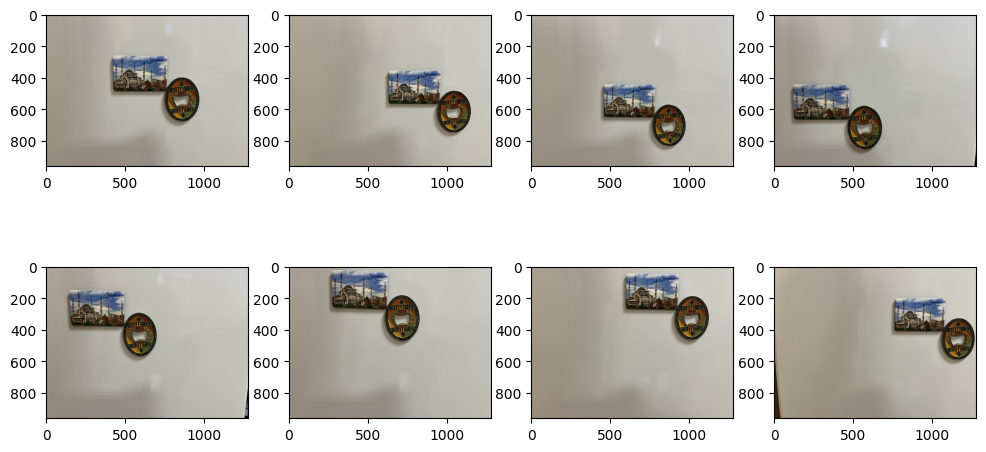

In [2]:
image1=cv2.cvtColor(cv2.imread('sequence1.jpeg'), cv2.COLOR_BGR2RGB)
image2=cv2.cvtColor(cv2.imread('sequence2.jpeg'), cv2.COLOR_BGR2RGB)
image3=cv2.cvtColor(cv2.imread('sequence3.jpeg'), cv2.COLOR_BGR2RGB)
image4=cv2.cvtColor(cv2.imread('sequence4.jpeg'), cv2.COLOR_BGR2RGB)
image5=cv2.cvtColor(cv2.imread('sequence5.jpeg'), cv2.COLOR_BGR2RGB)
image6=cv2.cvtColor(cv2.imread('sequence6.jpeg'), cv2.COLOR_BGR2RGB)
image7=cv2.cvtColor(cv2.imread('sequence7.jpeg'), cv2.COLOR_BGR2RGB)
image8=cv2.cvtColor(cv2.imread('sequence8.jpeg'), cv2.COLOR_BGR2RGB)

images_sequence = [image1, image2, image3, image4, image5, image6, image7, image8]

f, axarr = plt.subplots(2,4, figsize = (12,6))

axarr[0,0].imshow(image1)
axarr[0,1].imshow(image2)
axarr[0,2].imshow(image3)
axarr[0,3].imshow(image4)

axarr[1,0].imshow(image5)
axarr[1,1].imshow(image6)
axarr[1,2].imshow(image7)
axarr[1,3].imshow(image8)

Лирическое отступление - чтобы не размазывать отчет, работа будет вестись над grayscale изображениями. То что мы будем использовать - не зависит от цветов, как видно из первой лабы. Все что возможно - можно сделать для RGB повторяя те же операций и преобразования, просто трижды - по разу для каждого цветового канала. Это не цель лабораторной работы. Приступим, переведем изображения в черно-белый формат, используя функцию из прошлой лабы.

In [3]:
images_sequence_gray = []
for img in images_sequence:
    images_sequence_gray.append(lb1.intensity_grayscale(img))

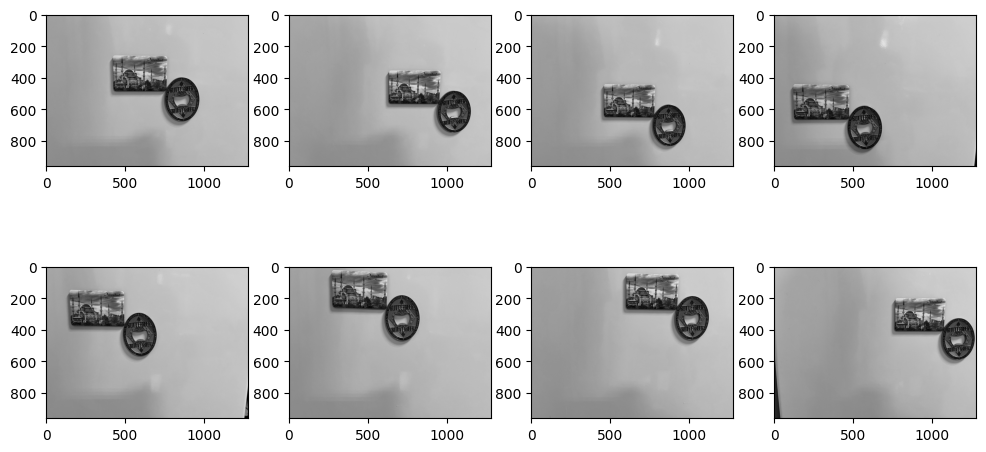

In [4]:
f, axarr = plt.subplots(2,4, figsize = (12,6))

axarr[0,0].imshow(images_sequence_gray[0], cmap='gray')
axarr[0,1].imshow(images_sequence_gray[1], cmap='gray')
axarr[0,2].imshow(images_sequence_gray[2], cmap='gray')
axarr[0,3].imshow(images_sequence_gray[3], cmap='gray')

axarr[1,0].imshow(images_sequence_gray[4], cmap='gray')
axarr[1,1].imshow(images_sequence_gray[5], cmap='gray')
axarr[1,2].imshow(images_sequence_gray[6], cmap='gray')
axarr[1,3].imshow(images_sequence_gray[7], cmap='gray')

То есть, нам нужно:

загрузить изображения, привести их к одинаковой яркости / grayscale, найти ключевые точки, отфильтровать точки, построить дескрипторы (SIFT), сопоставить точки между соседними кадрами, вычислить преобразование (поворот + сдвиг), накопить преобразования и построить траекторию камеры

Исправим проблемы с яркостью, применив реализованный модуль для выравнивания гистограммы:

# 2.2 Привести к одинаковой яркости / grayscale

для нашего удобства и ментального здоровья зададим функцию готовую для отображения картинок из серии:

In [5]:
def show_images(images_sequence, rows=2, cols=4, figsize=(12,6)):

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(images_sequence):
            ax.imshow(images_sequence[i], cmap='gray')
            ax.axis('off')  # убираем оси
        else:
            ax.axis('off')  # если картинок меньше, оставляем пустые

    plt.tight_layout()
    plt.show()

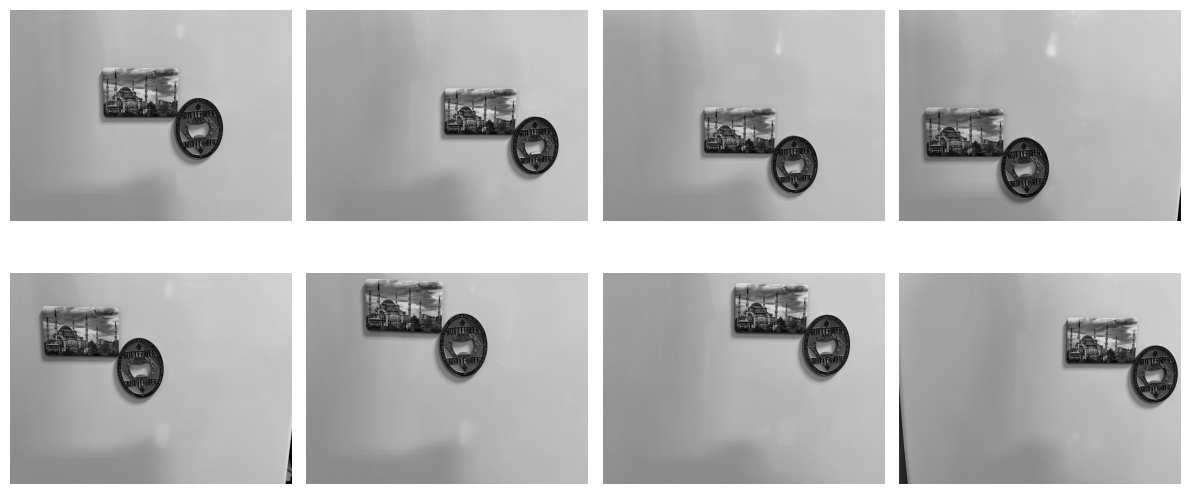

In [6]:
show_images(images_sequence_gray, 2, 4)

Супер. Вернемся к идее применить выравнивание гистограммы на всех изображениях:

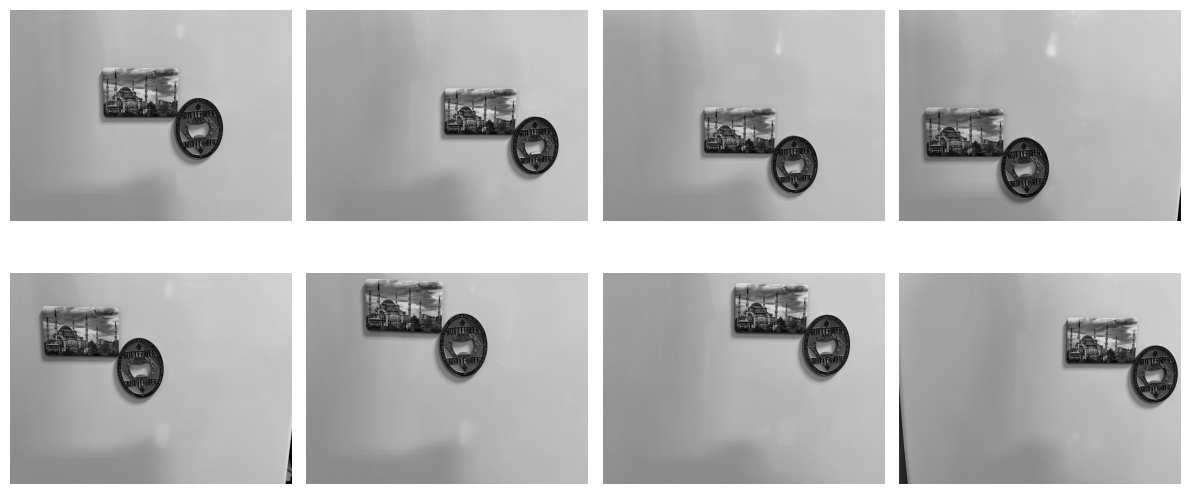

In [7]:
images_hist_equalized = images_sequence_gray
for img in images_hist_equalized:
    img = lb1.hist_equalize(img)
    
show_images(images_sequence_gray, 2, 4)

# 3.3 Найти ключевые точки

Приступаем. На изображениях у нас есть два магнита рядом, но нам могут значительно помешать: блики, тень от фотографа, другие нерелватные в этом контексте детали. Это визуальный <b>шум</b>. От шума надо избавиться, рассмотрим изображение 1, применим для подавления шумов фильтр Гаусса.

limits for Z kernel 1.0 1.0
limits for Z kernel after normalization 7.658057422279819e-32 0.11052426603583844
limits for gaussian output 2.4991448589236085 234.7124602763381


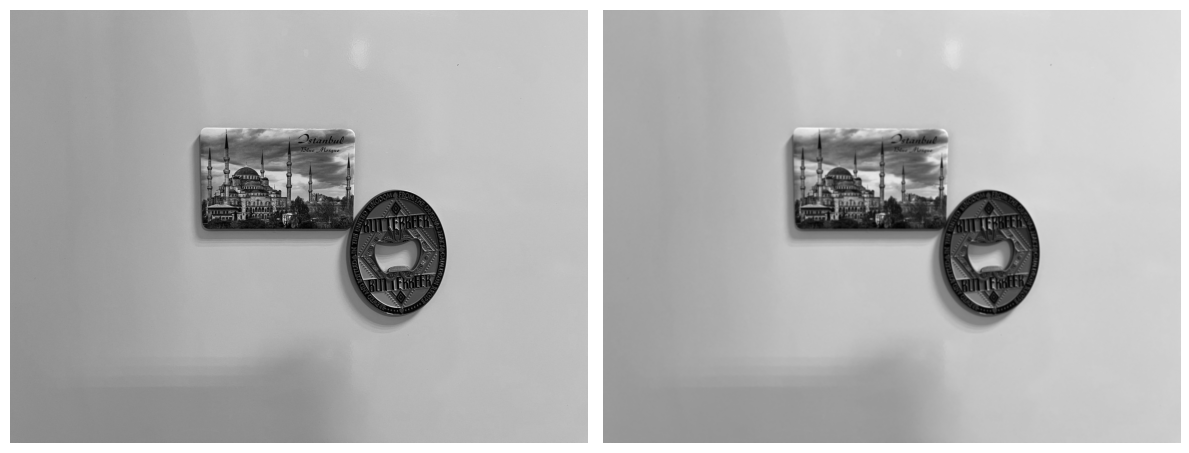

In [14]:
images_temp = [images_hist_equalized[0], lb1.gaussian_2d(images_hist_equalized[0], 1.2, 21)]
show_images(images_temp, 1, 2)

Стало слегка лучше. Теперь перейдем к теории:

Ключевые точки: это такие места, по которым сравнивая две картинки можно отследить движение.

Если бы мы смотрели на голубое небо и взяли его кусочек как ключевую точку, то распределение интенсивностей было бы +- одинаковое между ним и другим кусочком неба. Это плохая ключевая точка.

Если бы мы смотрели на фото прикроватной тумбочки, то могли бы предположить, что край тумбочки - хорошая ключевая точка, т.к. интенсивность прыгает на моменте перехода от края тумбочки к ее боковой части в тени. По идее - уже неплохо, но если двигаться вдоль этого края - ситуация не поменяется при сравнении двух кадров.

Из этого следует, что лучший вариант - когда меняются по двум направлениям тренды. Например, угол тумбочки. Вдоль него не подвигаться, то есть изменение интенсивности слева и спереди (перед стеной) достаточно легко отслеживаются.  

Из математики следует, что производная функции показывает скорость изменения ее значения. А градиент - вектор, показывающий <b>НАПРАВЛЕНИЕ</b> наибыстрейшего увеличения функции. Это то, что надо нам. Формула для градиента в общей форме выглядит так:

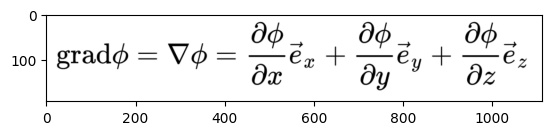

In [15]:
img = cv2.imread('./gradient.png')
plt.imshow(img)

Исходя из вышесказанного, понятно, что алгоритмы поиска ключевых точек ищут точки, где изменение яркости происходит во многих направлениях одновременно.

Математически - ищем градиенты изображения, по x и y координатам. 

Пусть I_x = изменение по х, I_y = изменение по y.
<p>Значит, место, где I_x = 0, I_y = 0 это однородная область.
<p>Если I_x большое, I_y маленькое = это край.
<p>Если I_x большое, I_y большое = это угол (ключевая точка).

Из опыта прошлой лабы мы понимаем, что смотреть на сам один пиксель недостаточно. Нужно брать апертуру/кернел/область/окно. Так и сделаем. Идейно по определению подходит фильтр Хариса. Источник: https://docs.exponenta.ru/R2021a/visionhdl/ug/corner-detection.html

# TO-DO Разберем этот фильтр

Фактически у нас есть исходное изображение, minor_size, k, threshold_ratio.

minor_size - так же как в прошлой лабе, размер апертуры/кернел/окно. маленькое окно = чувствительность к мелким деталям, большое окно = реагирует только на крупные структуры

источник: https://docs.opencv.org/3.4/dc/d0d/tutorial_py_features_harris.html
<p> k - коэффициент, испольуемый в формуле Хариса:

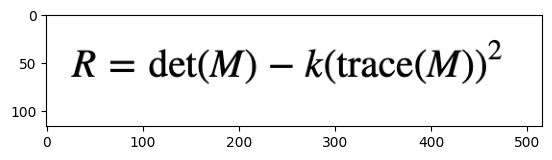

In [33]:
img = cv2.imread('./harris1.png')
plt.imshow(img)

Этот коэффициент регулирует насколько алгоритм строго смотрит края.
<p>Маленький = алгоритм более терпим к краям, может принимать некоторые края за углы
<p>Большой = алгоритм строгий, оставляет только очень выраженные углы

threshold_ratio

После вычисления Harris response R нужно решить какие точки считать ключевыми.

Для этого берётся максимум:
R_max = max(R)

и строится порог:

threshold = threshold_ratio * R_max

Если threshold_ratio = 0.01, то берутся точки у которых R > 1% от максимального

Если увеличить до 0.1 = останутся только самые сильные углы.

In [ ]:
def harris_keypoints(image, minor_size=5, k=0.04, threshold_ratio=0.01):

    if len(image.shape) == 3:
        image = intensity_grayscale(image)

    image = image.astype(float)

    height, width = image.shape

    Ix = np.zeros_like(image)
    Iy = np.zeros_like(image)

    # градиенты (центральные разности)
    for r in range(1, height-1):
        for c in range(1, width-1):
            Ix[r][c] = (image[r][c+1] - image[r][c-1]) / 2
            Iy[r][c] = (image[r+1][c] - image[r-1][c]) / 2

    pad = minor_size // 2

    R = np.zeros_like(image)

    for r in range(pad, height-pad):
        for c in range(pad, width-pad):

            sum_Ix2 = 0
            sum_Iy2 = 0
            sum_Ixy = 0

            for i in range(-pad, pad+1):
                for j in range(-pad, pad+1):
                    gx = Ix[r+i][c+j]
                    gy = Iy[r+i][c+j]

                    sum_Ix2 += gx*gx
                    sum_Iy2 += gy*gy
                    sum_Ixy += gx*gy

            det = sum_Ix2 * sum_Iy2 - sum_Ixy**2
            trace = sum_Ix2 + sum_Iy2

            R[r][c] = det - k*(trace**2)

    R_max = np.max(R)
    threshold = threshold_ratio * R_max

    keypoints = []

    for r in range(pad, height-pad):
        for c in range(pad, width-pad):

            if R[r][c] > threshold:

                local_max = True

                for i in range(-1,2):
                    for j in range(-1,2):
                        if R[r+i][c+j] > R[r][c]:
                            local_max = False

                if local_max:
                    keypoints.append((r,c))

    return keypoints, Ix, Iy

In [17]:
def draw_keypoints(image, keypoints, Ix=None, Iy=None, show_vectors=False, vector_scale=5):

    img = image.copy()

    if len(img.shape) == 2:
        img = np.dstack((img,img,img))

    plt.figure(figsize=(8,6))
    plt.imshow(img)

    for (r,c) in keypoints:
        plt.scatter(c, r, s=20)

        if show_vectors and Ix is not None and Iy is not None:
            gx = Ix[r][c]
            gy = Iy[r][c]

            plt.arrow(c, r,
                      gx*vector_scale,
                      gy*vector_scale,
                      head_width=3,
                      length_includes_head=True)

    plt.axis("off")
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.4991448589236085..234.7124602763381].


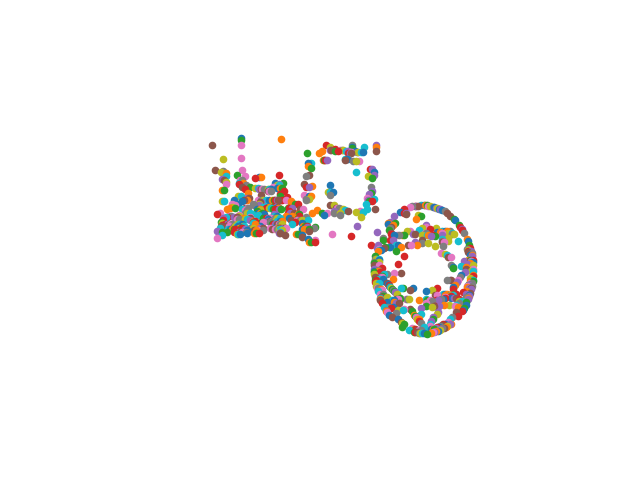

In [ ]:
gray = images_temp[1]

keypoints, Ix, Iy = harris_keypoints(gray, minor_size=9)

draw_keypoints(gray, keypoints)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.4991448589236085..234.7124602763381].


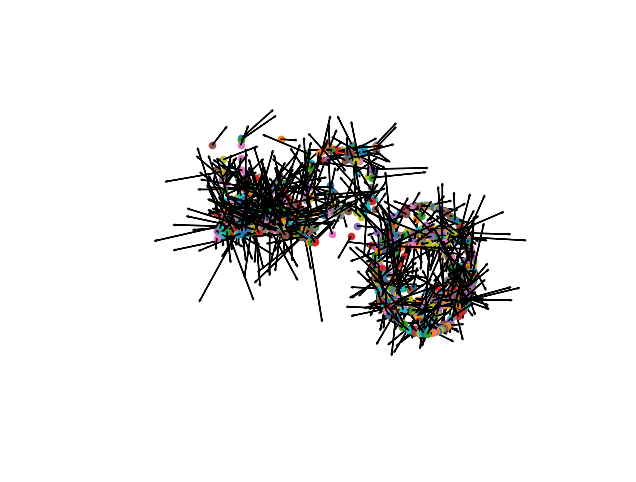

In [30]:
draw_keypoints(gray, keypoints, Ix, Iy, show_vectors=True)

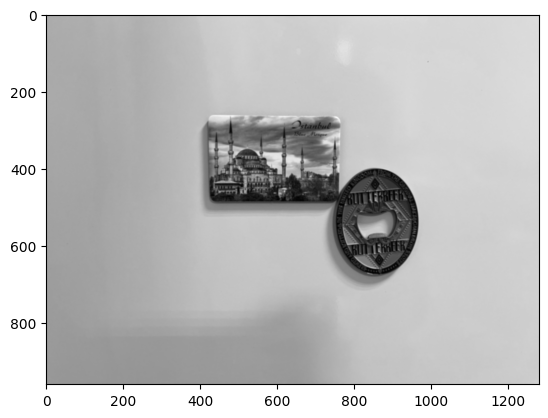

In [31]:
plt.imshow(images_temp[1], cmap='gray')

# 3.4 Отфильтровать точки

 # 3.5 Построить дескрипторы (SIFT)

# 3.6 Сопоставить точки между соседними кадрами

# 3.7 Вычислить преобразование (поворот + сдвиг)

# 3.8 Накопить преобразования и построить траекторию камеры